# County-level Tree (149 tips)

Time-scaled phylogenetic tree of 149 early B3.13 genomes with county-level
discrete trait reconstruction. 18 counties across 8 states.

- Host-specific tip markers (Cattle, Poultry, Other avian, Other mammal)
- Gradient branch coloring for location transitions
- Posterior circles: filled black >= 0.95, open white >= 0.65
- Root + children + grandchildren labeled

In [1]:
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import baltic as bt

plt.rcParams.update({
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = font
        break
    except:
        pass

PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
FIG_DIR = FINAL_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

TREE_PATH = (PAPER_DIR / 'analysis' / 'beast' / 'early_outbreak_county_level'
             / 'county_level_all_analysis' / 'updated' / 'gtr4'
             / 'county_level_all.fasta.aln.hipstr.tree')

# --- County / state definitions ---
COUNTIES_BY_STATE = {
    'TX': sorted(['TX_CASTRO', 'TX_DALLAM', 'TX_DEAF_SMITH', 'TX_HALE',
                  'TX_HARTLEY', 'TX_LAMB', 'TX_MOORE', 'TX_PARMER']),
    'KS': sorted(['KS_GRAY', 'KS_KEARNY', 'KS_SEWARD']),
    'NM': ['NM_CURRY'],
    'MI': sorted(['MI_IONIA', 'MI_MONTCALM']),
    'ID': ['ID_CASSIA'],
    'SD': ['SD_BROWN'],
    'OH': ['OH_WOOD'],
    'NC': ['NC_WAKE'],
}
STATE_ORDER = ['TX', 'KS', 'NM', 'MI', 'ID', 'SD', 'OH', 'NC']

_TX_SHADES = ['#b80000', '#cc2200', '#e41a1c', '#ff4466',
              '#d45500', '#ff7f00', '#e8a020', '#ff9944']
_KS_SHADES = ['#ffd92f', '#e6c400', '#ccaa00']
_MI_SHADES = ['#1f78b4', '#4a9fd4']
STATE_COLORS = {
    'NM': '#b2abd2', 'ID': '#7b3294', 'SD': '#fc8d62',
    'OH': '#c51b7d', 'NC': '#66c2a5',
}

COUNTY_COLORS = {}
for state, counties in COUNTIES_BY_STATE.items():
    if state == 'TX':
        for i, c in enumerate(counties):
            COUNTY_COLORS[c] = _TX_SHADES[i]
    elif state == 'KS':
        for i, c in enumerate(counties):
            COUNTY_COLORS[c] = _KS_SHADES[i]
    elif state == 'MI':
        for i, c in enumerate(counties):
            COUNTY_COLORS[c] = _MI_SHADES[i]
    else:
        COUNTY_COLORS[counties[0]] = STATE_COLORS[state]

HOST_MARKERS = {'Cattle': 'o', 'Poultry': '^', 'Other avian': 'D', 'Other mammal': 's'}
HOST_ORDER = ['Cattle', 'Poultry', 'Other avian', 'Other mammal']
N_GRADIENT_SEGMENTS = 30

print(f'Tree: {TREE_PATH}')
print(f'Output: {FIG_DIR}')
print(f'Counties: {sum(len(v) for v in COUNTIES_BY_STATE.values())} across {len(COUNTIES_BY_STATE)} states')

Tree: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/analysis/beast/early_outbreak_county_level/county_level_all_analysis/updated/gtr4/county_level_all.fasta.aln.hipstr.tree
Output: /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures
Counties: 18 across 8 states


In [2]:
# --- Helper functions ---

def _hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))


def _lerp_color(c1, c2, t):
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return (r1 + t * (r2 - r1), g1 + t * (g2 - g1), b1 + t * (b2 - b1))


def decimal_to_date(dy):
    y = int(dy)
    f = dy - y
    s = datetime(y, 1, 1)
    return s + timedelta(days=f * (datetime(y + 1, 1, 1) - s).days)


def _get_loc(n):
    return n.traits.get('loc', n.traits.get('loc.set', '??'))
# def _get_loc(n):
#     return n.traits.get('loc.rate', n.traits.get('loc.set', '??'))


def _get_color(loc):
    return COUNTY_COLORS.get(loc, '#aaaaaa')


def get_host_category(name):
    parts = name.split('|')
    host = parts[2] if len(parts) >= 3 else ''
    if host == 'cattle':
        return 'Cattle'
    elif host == 'chicken':
        return 'Poultry'
    elif host in ('grackle', 'pigeon'):
        return 'Other avian'
    else:
        return 'Other mammal'


print('Helpers defined.')

Helpers defined.


In [3]:
# --- Load and prepare tree ---
tree = bt.loadNexus(str(TREE_PATH), tip_regex=r'(\d{4}-\d{2}-\d{2})$', verbose=False)
tree.sortBranches(descending=True)
tree.drawTree()

tips = tree.getExternal()
max_y = max(n.y for n in tree.Objects)
obj_set = set(id(n) for n in tree.Objects)
observed_locs = set(_get_loc(n) for n in tree.Objects) - {'??'}

children_map = {}
for node in tree.Objects:
    if node.parent and id(node.parent) in obj_set:
        children_map.setdefault(id(node.parent), []).append(node)

internals = [n for n in tree.Objects if n.branchType != 'leaf']
n_high = sum(1 for n in internals if float(n.traits.get('loc.rate.prob', 0)) >= 0.90)
n_mod = sum(1 for n in internals if 0.65 <= float(n.traits.get('loc.rate.prob', 0)) < 0.90)

# Host categories
host_counts = {}
for tip in tips:
    cat = get_host_category(tip.name)
    host_counts[cat] = host_counts.get(cat, 0) + 1

# Root info
root = next(n for n in tree.Objects if not n.parent or id(n.parent) not in obj_set)
root_loc = _get_loc(root)
root_prob = float(root.traits.get('loc.rate.prob', 0))

print(f'{len(tips)} tips, {len(tree.Objects)} total nodes')
print(f'{len(observed_locs)} unique MAP locations: {sorted(observed_locs)}')
print(f'Posterior support: {n_high} nodes >= 0.90, {n_mod} nodes >= 0.65')
print(f'Host categories: {host_counts}')
print(f'Root: {root_loc} (posterior = {root_prob:.4f})')

149 tips, 297 total nodes
18 unique MAP locations: ['ID_CASSIA', 'KS_GRAY', 'KS_KEARNY', 'KS_SEWARD', 'MI_IONIA', 'MI_MONTCALM', 'NC_WAKE', 'NM_CURRY', 'OH_WOOD', 'SD_BROWN', 'TX_CASTRO', 'TX_DALLAM', 'TX_DEAF_SMITH', 'TX_HALE', 'TX_HARTLEY', 'TX_LAMB', 'TX_MOORE', 'TX_PARMER']
Posterior support: 0 nodes >= 0.90, 0 nodes >= 0.65
Host categories: {'Cattle': 130, 'Poultry': 12, 'Other mammal': 5, 'Other avian': 2}
Root: TX_CASTRO (posterior = 0.0000)


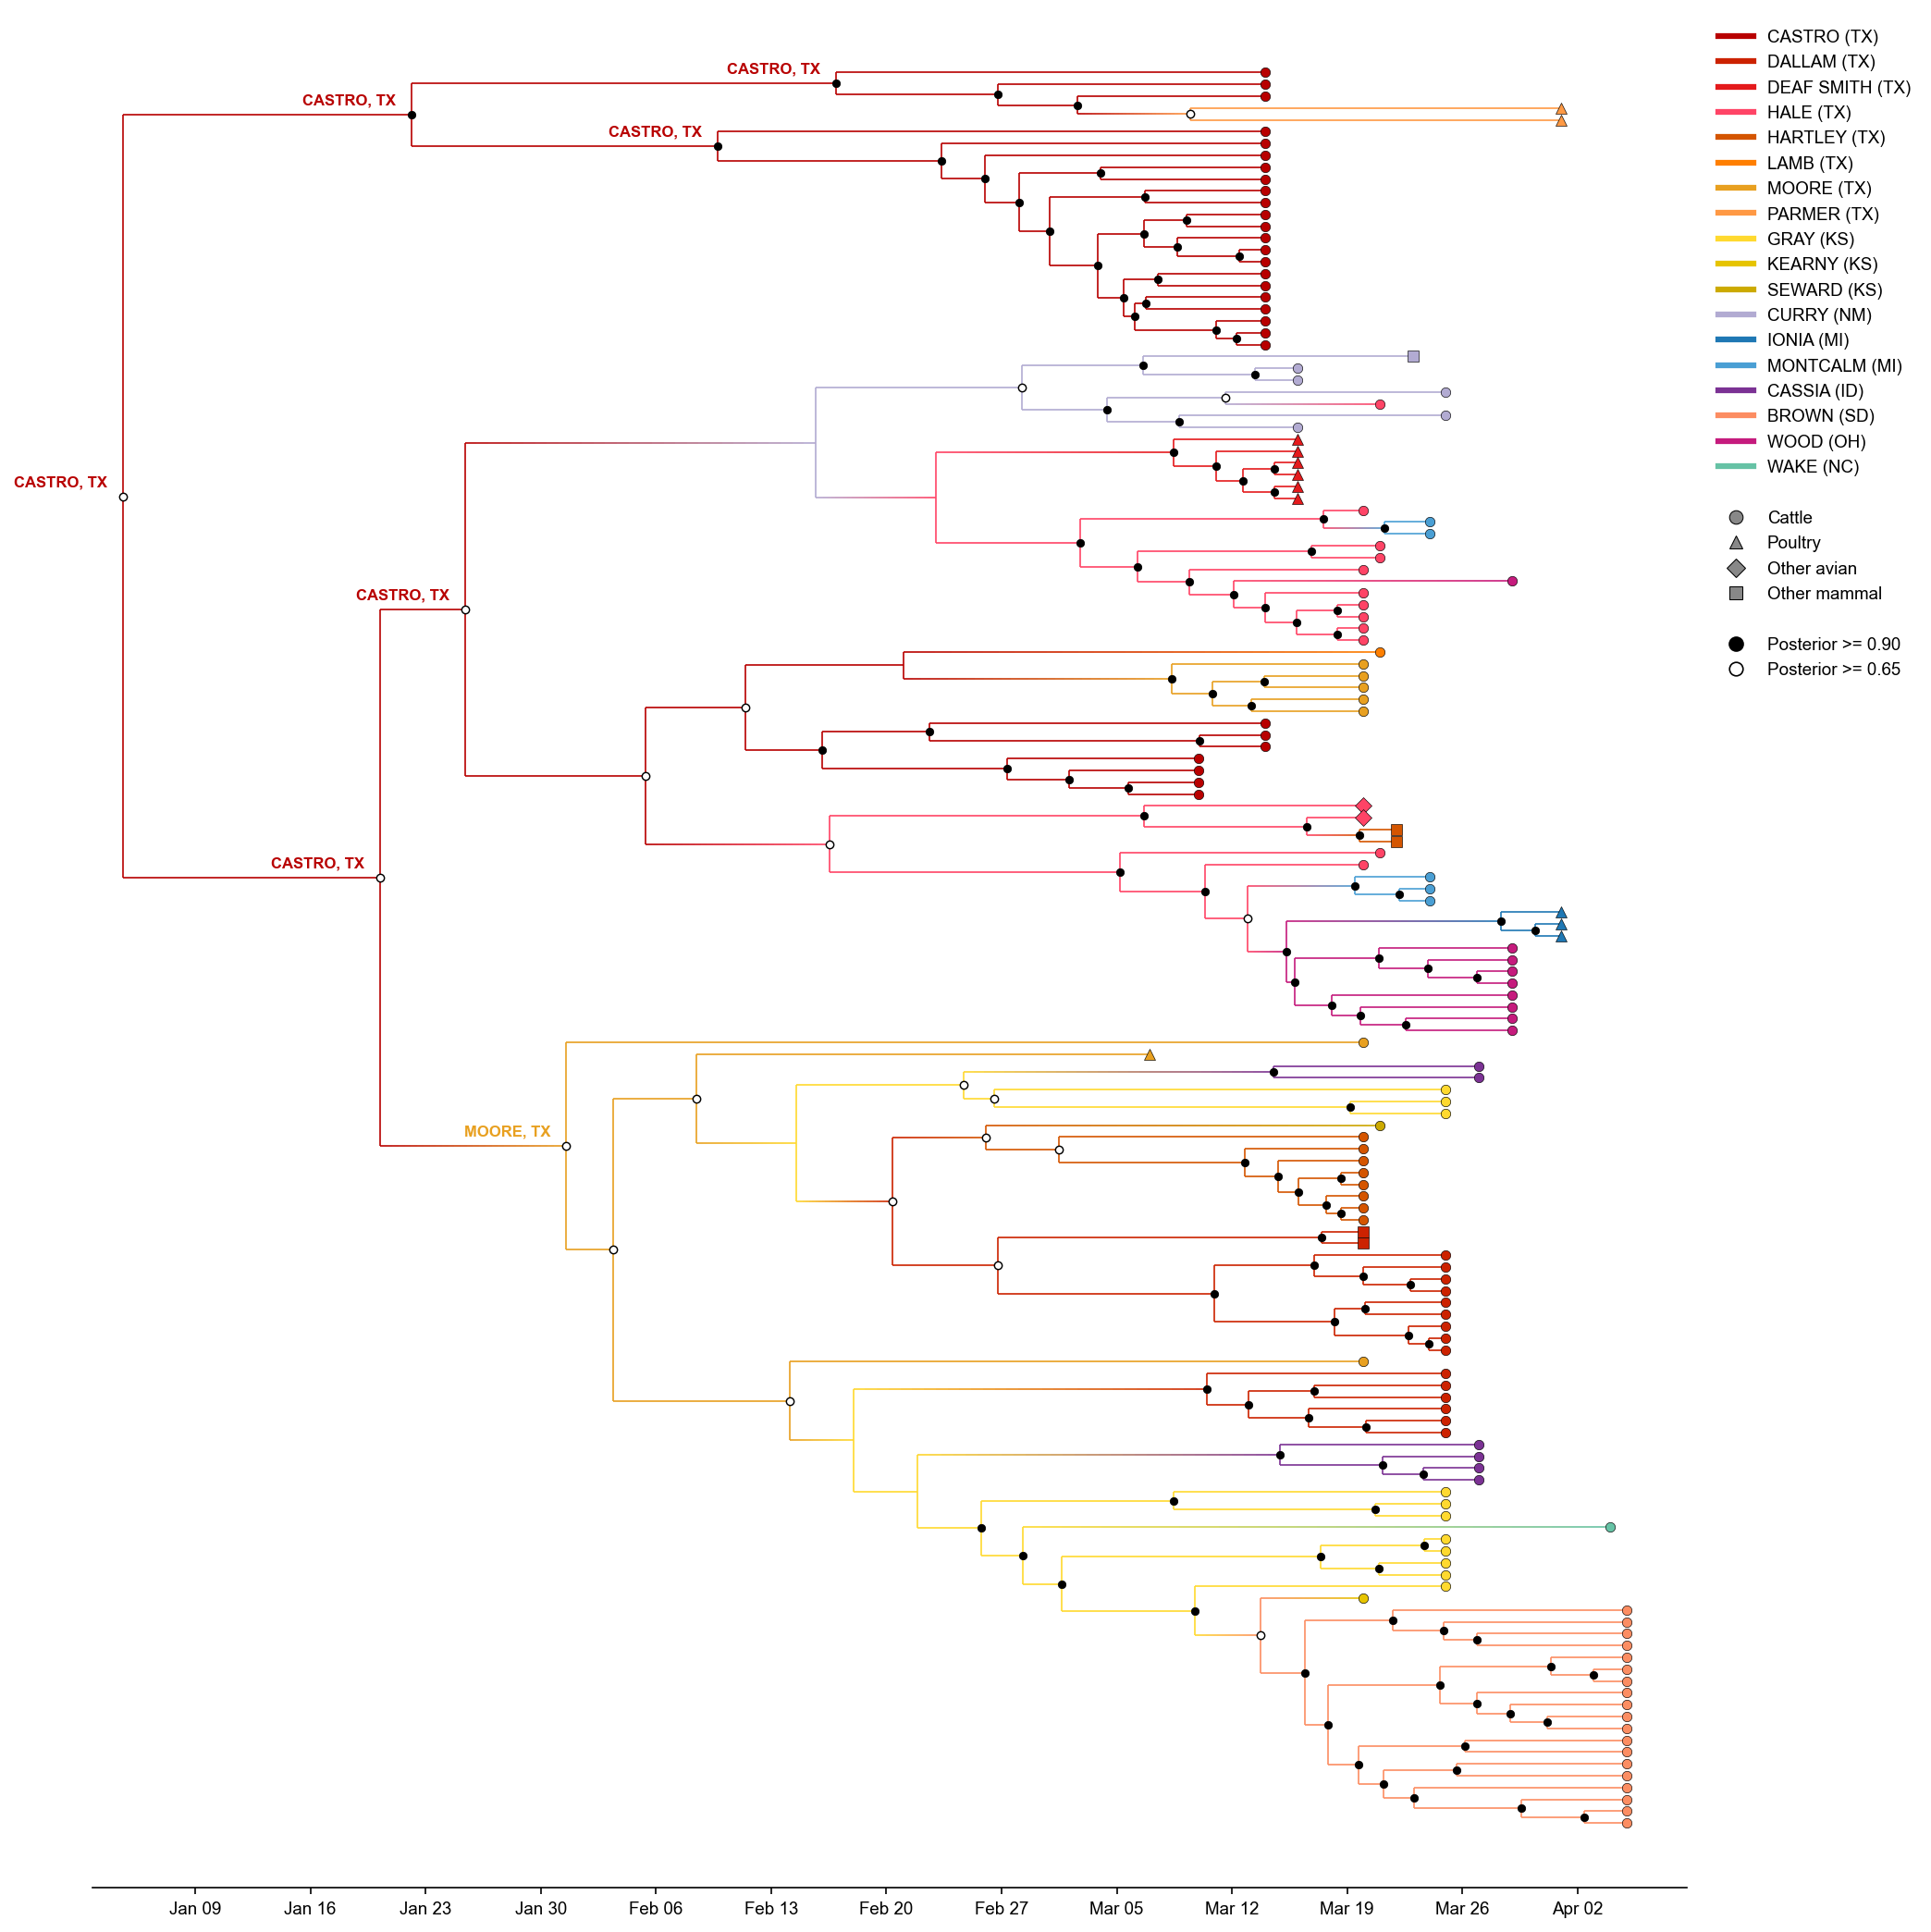

In [4]:
# --- Draw tree ---
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

h_lines, h_colors, v_lines, v_colors = [], [], [], []

for node in tree.Objects:
    loc = _get_loc(node)
    color = _get_color(loc)
    y_pos = node.y

    if node.parent and id(node.parent) in obj_set:
        p_loc = _get_loc(node.parent)
        p_color = _get_color(p_loc)
        x0 = mdates.date2num(decimal_to_date(node.parent.absoluteTime))
        x1 = mdates.date2num(decimal_to_date(node.absoluteTime))

        if p_loc == loc:
            h_lines.append([(x0, y_pos), (x1, y_pos)])
            h_colors.append(color)
        else:
            for si in range(N_GRADIENT_SEGMENTS):
                f0 = si / N_GRADIENT_SEGMENTS
                f1 = (si + 1) / N_GRADIENT_SEGMENTS
                h_lines.append([(x0 + f0 * (x1 - x0), y_pos),
                                (x0 + f1 * (x1 - x0), y_pos)])
                h_colors.append(_lerp_color(p_color, color, (f0 + f1) / 2))

    kids = children_map.get(id(node), [])
    if kids:
        cy = [c.y for c in kids]
        xn = mdates.date2num(decimal_to_date(node.absoluteTime))
        v_lines.append([(xn, min(cy)), (xn, max(cy))])
        v_colors.append(color)

ax.add_collection(LineCollection(h_lines, colors=h_colors, linewidths=0.8, zorder=2))
ax.add_collection(LineCollection(v_lines, colors=v_colors, linewidths=0.8, zorder=1))

# Posterior support circles
for node in tree.Objects:
    if node.branchType == 'leaf':
        continue
    try:
        prob = float(node.traits.get('loc.prob', 0))
    except (TypeError, ValueError):
        continue
    x_pos = mdates.date2num(decimal_to_date(node.absoluteTime))
    y_pos = node.y
    if prob >= 0.90:
        ax.plot(x_pos, y_pos, 'o', markersize=4, color='black',
                markeredgecolor='black', markeredgewidth=0.4, zorder=5)
    elif prob >= 0.65:
        ax.plot(x_pos, y_pos, 'o', markersize=4, color='white',
                markeredgecolor='black', markeredgewidth=0.7, zorder=5)

# Host-specific tip markers
for tip in tips:
    color = _get_color(_get_loc(tip))
    x_pos = mdates.date2num(decimal_to_date(tip.absoluteTime))
    y_pos = tip.y
    cat = get_host_category(tip.name)
    ax.plot(x_pos, y_pos, marker=HOST_MARKERS[cat],
            markersize=5 if cat == 'Cattle' else 6,
            color=color, markeredgecolor='black', markeredgewidth=0.3, zorder=6)

# Label root, children, grandchildren
root_children = [n for n in tree.Objects if n.parent and id(n.parent) == id(root)]
grandchildren = []
for rc in root_children:
    grandchildren.extend([n for n in tree.Objects
                          if n.parent and id(n.parent) == id(rc) and n.is_node()])

label_nodes = [root] + root_children + grandchildren
for node in label_nodes:
    loc = _get_loc(node)
    x_pos = mdates.date2num(decimal_to_date(node.absoluteTime))
    y_pos = node.y
    label = loc.replace('_', ' ')
    parts = label.split(' ', 1)
    label = f'{parts[1]}, {parts[0]}' if len(parts) > 1 else label
    ax.annotate(label, xy=(x_pos, y_pos), xytext=(-8, 4),
                textcoords='offset points', fontsize=8, fontweight='bold',
                ha='right', va='bottom', color=_get_color(loc), zorder=10)

# Axes
ax.set_xlim(
    mdates.date2num(decimal_to_date(min(n.absoluteTime for n in tree.Objects) - 0.005)),
    mdates.date2num(decimal_to_date(max(n.absoluteTime for n in tree.Objects) + 0.01)),
)
ax.set_ylim(-5, max_y + 5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Legend
handles = []
for state in STATE_ORDER:
    for county in COUNTIES_BY_STATE[state]:
        if county not in observed_locs:
            continue
        label = county.replace('_', ' ')
        parts = label.split(' ', 1)
        label = f'{parts[1]} ({parts[0]})' if len(parts) > 1 else label
        handles.append(Line2D([0], [0], color=COUNTY_COLORS[county],
                              linewidth=3, label=label))

handles.append(Line2D([], [], color='none', label=''))
for cat in HOST_ORDER:
    handles.append(Line2D([], [], marker=HOST_MARKERS[cat], color='none',
                          markerfacecolor='#888888', markeredgecolor='black',
                          markersize=7, markeredgewidth=0.5, label=cat))

handles.append(Line2D([], [], color='none', label=''))
handles.append(Line2D([], [], marker='o', color='none', markerfacecolor='black',
                      markeredgecolor='black', markersize=7,
                      label='Posterior >= 0.90'))
handles.append(Line2D([], [], marker='o', color='none', markerfacecolor='white',
                      markeredgecolor='black', markersize=7, markeredgewidth=0.8,
                      label='Posterior >= 0.65'))

ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1.0),
          fontsize=9, frameon=False, edgecolor='#cccccc', ncol=1,
          handlelength=2.0, labelspacing=0.5)

fig.tight_layout()
# fig.savefig(FIG_DIR / 'S_CountyHiPSTrTree_149tip.png', dpi=300, bbox_inches='tight')
# fig.savefig(FIG_DIR / 'S_CountyHiPSTrTree_149tip.pdf', bbox_inches='tight')
# print(f'Saved to {FIG_DIR / "S_CountyHiPSTrTree_149tip"}.png/.pdf')
plt.show()